In [36]:
import numpy as np



In [37]:
img = np.array(
    [
        [1, 1, 0, 0, 0, 0, 0, 0],
        [0, 1, 1, 0, 0, 0, 0, 0],
        [0, 0, 1, 1, 0, 0, 0, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 0, 0],
        [0, 0, 0, 0, 0, 1, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 1],
    ]
)

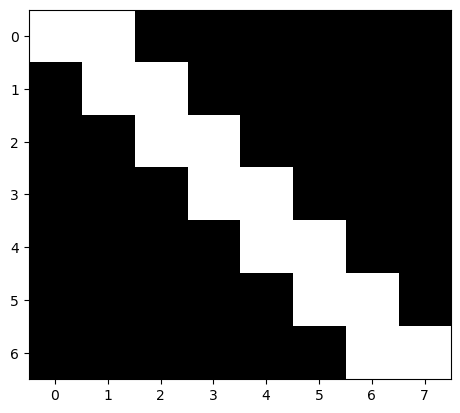

In [38]:
import matplotlib.pyplot as plt


plt.imshow(img, cmap="gray")

In [39]:
kernel = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ]
)




In [58]:
def convolve2d(image, kernel):
    kernel_height, kernel_width = kernel.shape
    image_height, image_width = image.shape

    output_height = image_height - kernel_height + 1
    output_width = image_width - kernel_width + 1

    output = np.zeros((output_height, output_width))

    for i in range(output_height):
        for j in range(output_width):
            region = image[i : i + kernel_height, j : j + kernel_width]
            output[i, j] = np.sum(region * kernel)

    return output

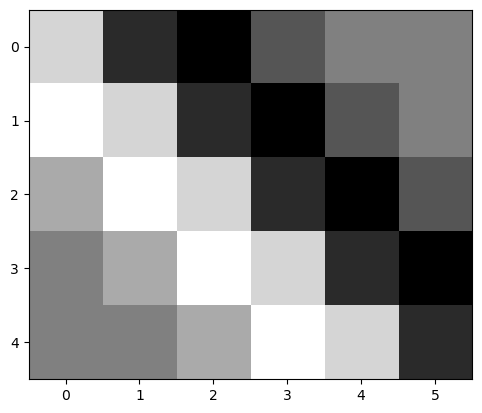

In [41]:
plt.imshow(convolve2d(img, kernel), cmap="gray")

In [56]:
img = plt.imread("cat.png")

# Convert to grayscale only when needed
if img.ndim == 3:
    img = np.mean(img[..., :3], axis=2)

img = img.astype(float)
if img.max() > 1.0:
    img = img / 255.0

img.shape

(900, 1200)

In [57]:
from skimage.transform import resize

# Resize less aggressively to preserve edges
img = resize(img, (256, 256), anti_aliasing=True)
img.shape

(256, 256)

(np.float64(-0.5), np.float64(253.5), np.float64(253.5), np.float64(-0.5))

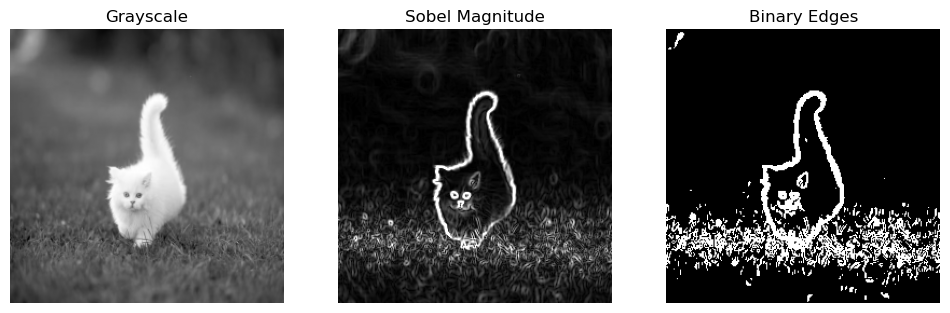

In [59]:
sobel_x = np.array(
    [
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1],
    ]
)

sobel_y = np.array(
    [
        [-1, -2, -1],
        [0, 0, 0],
        [1, 2, 1],
    ]
)

grad_x = convolve2d(img, sobel_x)
grad_y = convolve2d(img, sobel_y)
edge_map = np.sqrt(grad_x**2 + grad_y**2)

# Robust normalization for display contrast
scale = np.percentile(edge_map, 99)
if scale > 0:
    edge_map = np.clip(edge_map / scale, 0, 1)

binary_edges = edge_map > 0.25

plt.figure(figsize=(12, 4))
plt.subplot(1, 3, 1)
plt.title("Grayscale")
plt.imshow(img, cmap="gray")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.title("Sobel Magnitude")
plt.imshow(edge_map, cmap="gray", vmin=0, vmax=1)
plt.axis("off")

plt.subplot(1, 3, 3)
plt.title("Binary Edges")
plt.imshow(binary_edges, cmap="gray")
plt.axis("off")